In [30]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from PIL import Image

torch.hub.set_dir("../model_cache/torch/hub")
import sys
sys.path.append("/mnt/home/mizrahiulysse/ElasticDino")
from elasticdino.model.elasticdino import ElasticDino

def get_edino():
    edino = ElasticDino.from_pretrained("/mnt/home/mizrahiulysse/pixelvit-32-L.pth", "elasticdino-32-L", dino_repo="/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main")
    edino.eval()
    edino.requires_grad_ = False
    return edino

# edino = get_edino().cuda()
edino = torch.compile(get_edino().cuda())

In [ ]:
import os

HYPERSIM_PATHS = []
N_HYPERSIM_IMAGES = 6
HYPERSIM_BASE_PATH = "/mnt/home/mizrahiulysse/datasets/hypersim/"

for path in os.listdir(HYPERSIM_BASE_PATH):
    for subpath in os.listdir(os.path.join(HYPERSIM_BASE_PATH, path, "images")):
        frames = os.listdir(os.path.join(HYPERSIM_BASE_PATH, path, "images", subpath))
        frames = [x for x in frames if "color" in x]
        for f in frames:
            HYPERSIM_PATHS.append(os.path.join(HYPERSIM_BASE_PATH, path, "images", subpath, f))

TRAIN_PROPORTION = 0.8

train_size = int(len(HYPERSIM_PATHS) * TRAIN_PROPORTION)
HYPERSIM_TRAIN_PATHS = HYPERSIM_PATHS[:train_size]
HYPERSIM_TEST_PATHS = HYPERSIM_PATHS[train_size:]


In [23]:
# from elasticdino.data.imagenet import load_imagenet
# BATCH_SIZE=2
# dataloader = load_imagenet("/mnt/home/mizrahiulysse/datasets/imagenet-1k-256/imagenet/train", BATCH_SIZE, image_size=256)


IMAGE_SIZE = 128

def process_image(img):
    l = min(img.height, img.width)
    return img.convert("RGB").crop((0, 0, l, l)).resize((IMAGE_SIZE, IMAGE_SIZE))

    
def hypersim_sample(p):
    folder = os.path.dirname(p)
    f = p.split("/")[-1].split(".")[1]
    
    img = process_image(Image.open(os.path.join(folder, f"frame.{f}.color.jpg")))
    img =  torchvision.transforms.functional.pil_to_tensor(img)/255.0
    return img

class HypersimDataset(torch.utils.data.Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        return hypersim_sample(path)



hypersim_train_ds = HypersimDataset(HYPERSIM_TRAIN_PATHS)
hypersim_test_ds = HypersimDataset(HYPERSIM_TEST_PATHS)


In [55]:
import kornia


@torch.compile
def compute_loss_single(pred, gt):
    gt = nn.functional.interpolate(gt, pred.shape[-1], mode="bilinear")
    return (pred - gt).square().mean() + 1 * kornia.losses.ssim_loss(pred, gt, 11)

def compute_loss(results, features_large):
    loss = 0.0
    for r in results:
        loss += compute_loss_single(r, features_large)
    return loss / len(results)

0.5222699642181396


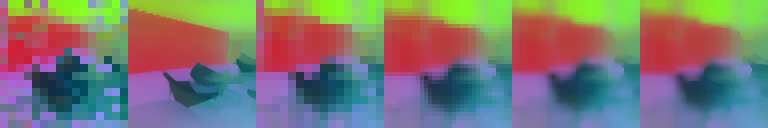

0.4952850937843323


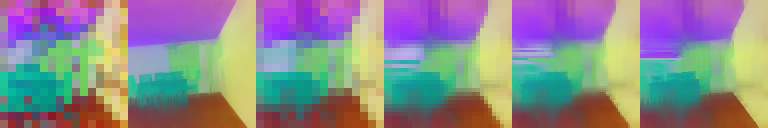

0.4900299310684204


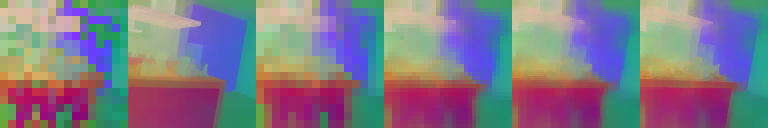

0.576491117477417


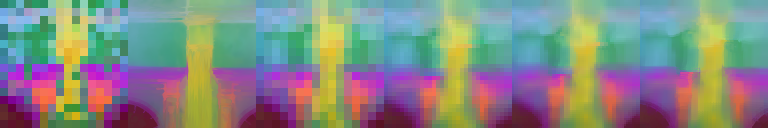

0.5110017657279968


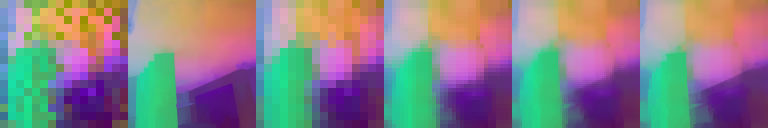

0.47985097765922546


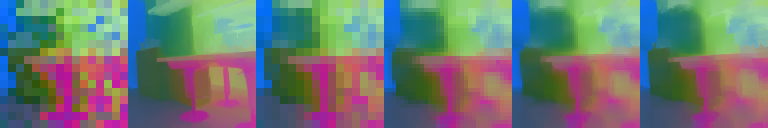

0.46126264333724976


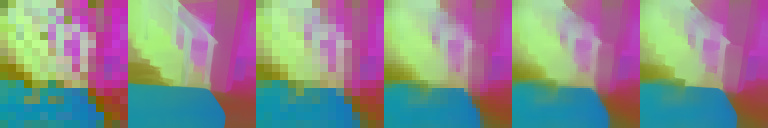

0.4670006036758423


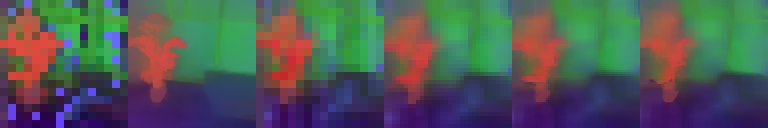

0.44931691884994507


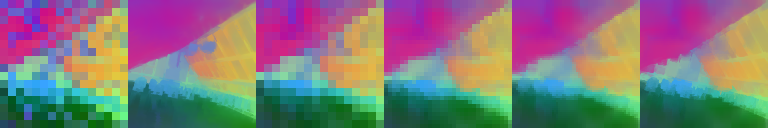

0.43962767720222473


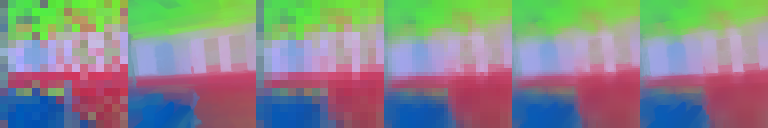

0.4305610656738281


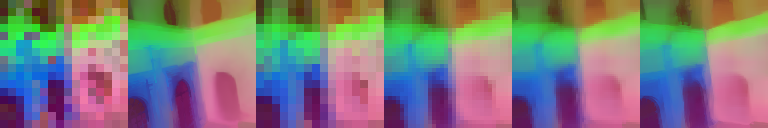

0.41854599118232727


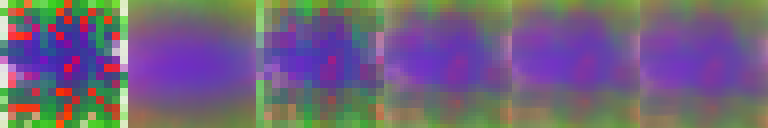

0.41758641600608826


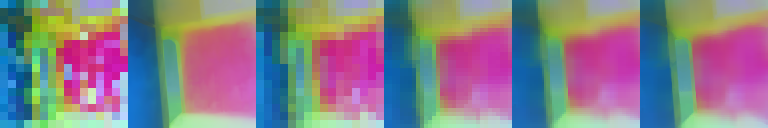

In [ ]:
from elasticdino.model.layers import ResidualBlock, Activation, ProjectionLayer, DepthwiseConvolution
from elasticdino.model.elasticdino import DeformerBlock

torch.set_float32_matmul_precision('medium')
torch.backends.cudnn.benchmark = True

class InvertedResidualBlock(nn.Module):
    def __init__(self, n_features, ratio=1):
        super().__init__()
        self.layers = nn.Sequential(
            DepthwiseConvolution(n_features, n_features // ratio, 3, padding=1),
            nn.BatchNorm2d(n_features // ratio),
            nn.ReLU(True),
            DepthwiseConvolution(n_features // ratio, n_features, 3, padding=1),
            nn.BatchNorm2d( n_features),
            nn.ReLU(True),
        )
    def forward(self, x):
        return x + self.layers(x)
        
class LocalAttentionBlock(nn.Module):
    def __init__(self, n_features=1024):
        super().__init__()
        self.input = InvertedResidualBlock(n_features)
        self.att = nn.Sequential(DepthwiseConvolution(n_features, n_features, 3, padding=1, bias=False), 
                                 nn.BatchNorm2d(n_features),
                                 nn.Tanh())
        self.out = InvertedResidualBlock(n_features)

    def forward(self, x):
        x = x + self.input(x) * self.att(x)
        return self.out(x)

class UpBlock(nn.Module):
    def __init__(self, n_features=1024):
        super().__init__()
        self.image_encoder = nn.Sequential(
            ProjectionLayer(3, n_features),
        )
        self.deformer = DeformerBlock(n_layers=3, n_features=256, n_features_in=1024, n_image_features=3)
        self.refiner = nn.Sequential(
            ProjectionLayer(n_features * 2, n_features),
            ResidualBlock(n_features),
            ResidualBlock(n_features),
            ResidualBlock(n_features),
            ResidualBlock(n_features),
            # LocalAttentionBlock(n_features),
        )

    def forward(self, image, features):
        features = self.deformer(features, image)["features"]
        return features + self.refiner(torch.cat([features, self.image_encoder(image)], dim=1))
        
import math

class Model(nn.Module):
    def __init__(self, target_size, n_features=1024):
        super().__init__()
        n_scales = int(math.log2(target_size // 16)) + 1
        
        self.layers = nn.ModuleList([UpBlock() for _ in range(n_scales)])

    def forward(self, image, features):
        current_size = 16
        results = []
        for layer in self.layers:
            features = nn.functional.interpolate(features, current_size, mode="nearest")
            features = layer(
                nn.functional.interpolate(image, current_size, mode="bilinear"),
                features
            )
            results.append(features)
            current_size *= 2
        return results
        


from elasticdino.training.util import debug_features
from IPython.display import display

def train(batch_size=4, max_iterations=None, size=128, debug_interval=10, n_epochs=10):
  model = Model(size).cuda()

  dataloader = torch.utils.data.DataLoader(hypersim_train_ds, batch_size=batch_size, shuffle=True, pin_memory=False, num_workers=32)
  
  import bitsandbytes
  optimizer = bitsandbytes.optim.AdamW8bit(
        [{"params": model.parameters(), "lr": 1e-3}], eps=1e-5, weight_decay=1e-5)
  scaler = torch.amp.GradScaler()
    
  running_loss = None
  n = 0

  print("Start training")
  for epoch in range(n_epochs):
    print("Epoch", epoch)
    for images in dataloader:
        if n == max_iterations:
          return
        images = images.cuda()
        n += 1
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            with torch.no_grad():
                features_large = edino(images)
                features_large = torch.nn.functional.interpolate(features_large, size)
                features_small = edino.dino.get_features_for_tensor(torch.nn.functional.interpolate(images, 224))
                images = torch.nn.functional.interpolate(images, size)
            results = model(images, features_small)
            loss = compute_loss(results, features_large)
        scaler.scale(loss).backward()
        # scaler.unscale_(optimizer)
        # torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        
        scaler.step(optimizer)
        scaler.update()

        optimizer.zero_grad()

        if running_loss is None:
          running_loss = loss.detach()
        else:
          running_loss = 0.98 * running_loss + 0.02 * loss.detach()  
            
        if n % debug_interval == 0:
            print(running_loss.item())
            display(debug_features(features_small[0], [features_large[0], *[pred[0] for pred in results]]))
            # !nvidia-smi
        del features_large
        del features_small
        del images
        del loss
        del results
        
    
            
train(batch_size=8, debug_interval=100)